# Time Series Analysis: Clustering

**Grouping** similar time series together is a vital data **exploration** technique. 

A comprehensive study building on top of the survey shown in the lecture evaluates many known (time series) clustering algorithms. It further evaluates different distance methods and techniques which can improve clustering results. <br> One of the main findings of the study was that the baseline k-Shapes was rarely exceeded, notably also not by Deep Learning Models.

We will be exploring four algorithms:
- **AH Clustering**: Standard Clustering Algorithm merging clusters iteratively
- **k-Means**: Standard Clustering Algorithm based on centroids
- **k-Shapes**: Similar to k-Means, but improved for time series
- **DBSCAN**: Standard Clustering Algorithm grouping dense regions

This notebook also gives a quick introduction to evaluating clustering quality and finding cluster algorithm parameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import zscore

import meteostat as ms
from datetime import datetime

np.random.seed(42) # for reproducability

Lets import some weather data of multiple sensors around bolzano for a given year:

In [2]:
bolzano = ms.Point(46.5, 11.35, 262)  

# Get nearby weather stations
stations = ms.stations.nearby(bolzano, limit=50, radius=1000000)
station_ids = stations.index.tolist()

year = 2023
start = datetime(year, 1, 1)
end = datetime(year, 12, 31)

ms.config.block_large_requests = False
data = ms.hourly(station=station_ids, start=start, end=end, parameters=["temp"])

df_temp = data.fetch().reset_index().pivot(index='time', columns='station', values='temp').dropna(axis=1, how="all")

We are creating our clusters artificially by cutting the year's weather data into its quarters. These quarters basically represent the seasons of the year.

In [ ]:
# Split the data into 4 equal chunks (Seasons)
n_hours = len(df_temp)
cutoff = n_hours - (n_hours % 4) 
df_trimmed = df_temp.iloc[:cutoff]
season_chunks = np.split(df_trimmed, 4)

# Reshape for Clustering
samples = []
ground_truth_labels = [] 
season_names = ['Q1 (Winter)', 'Q2 (Spring)', 'Q3 (Summer)', 'Q4 (Fall)']

for i, chunk in enumerate(season_chunks):
    chunk_t = chunk.T # Transpose so rows = stations, columns = hours
    samples.append(chunk_t)
    
    ground_truth_labels.extend([season_names[i]] * len(chunk_t))

# Final Data
cluster_data = zscore(np.vstack(samples).astype(np.float64), axis=1)
cluster_data_labels = np.array(ground_truth_labels)

In [33]:
# Providing a PAA version for later use
from tslearn.piecewise import PiecewiseAggregateApproximation

n_paa_segments = 90 # Roughly daily averages
paa = PiecewiseAggregateApproximation(n_segments=n_paa_segments)
cluster_paa = paa.fit_transform(np.expand_dims(cluster_data, axis=-1))[:, :, 0]

The plot below shows an example of just 20 of the time series in the resulting dataset. 

Overlaying them already shows the difficulty of clustering. But they can be cleanly split into their respective clusters:

148 time series of length 2184


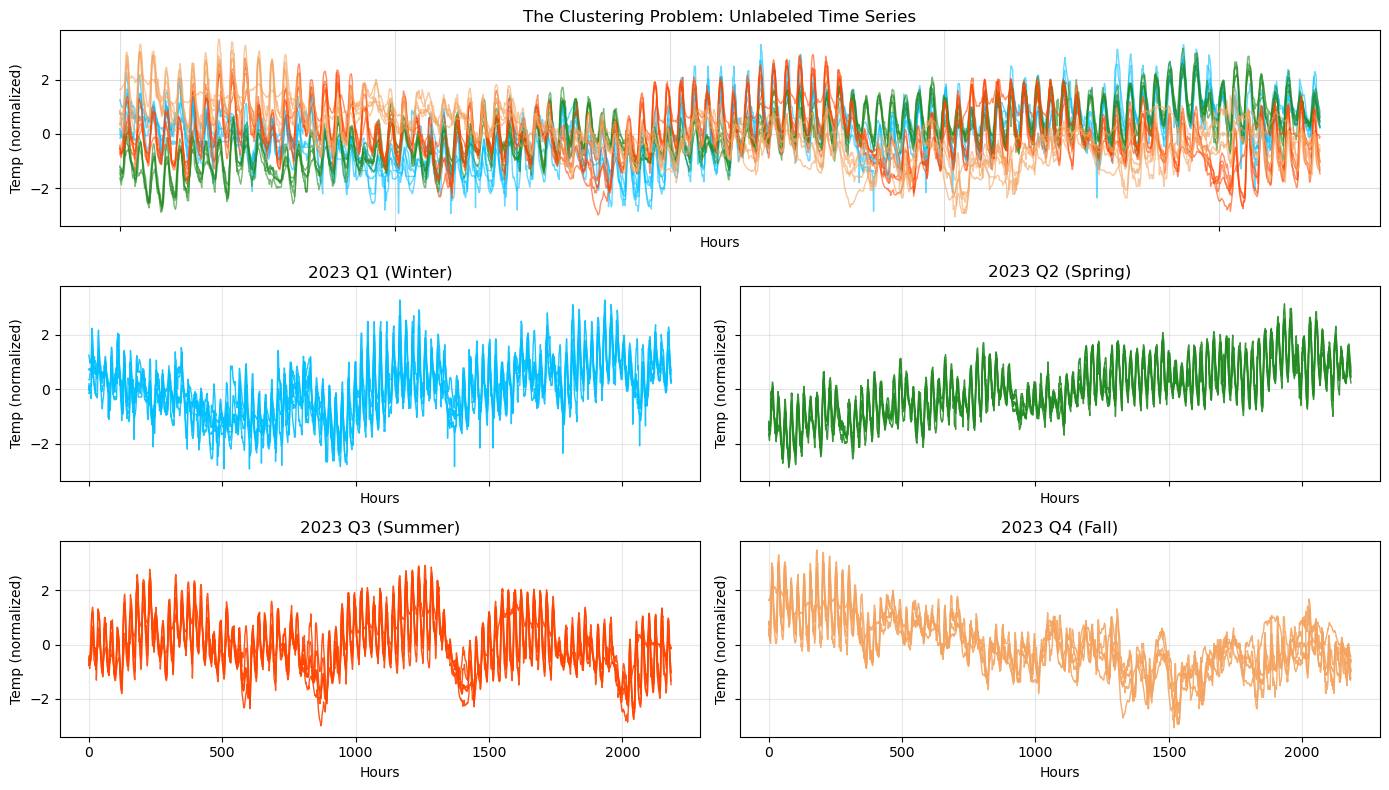

In [4]:
print(f"{cluster_data.shape[0]} time series of length {cluster_data.shape[1]}")

fig, ax = plt.subplot_mosaic([['main', 'main'], ['s0', 's1'], ['s2', 's3']], figsize=(14, 8), sharex=True, sharey=True)
colors = ['deepskyblue', 'forestgreen', 'orangered', 'sandybrown']

for i, (season, color) in enumerate(zip(np.unique(cluster_data_labels), colors)):
    sub_ax = ax[f's{i}']
    
    # Grab 5 random indices for this season
    samples = np.random.choice(np.where(cluster_data_labels == season)[0], 5, replace=False)
    for idx in samples:
        sub_ax.plot(cluster_data[idx], color=color, alpha=0.9, lw=1)       # Plot on grid
        ax['main'].plot(cluster_data[idx], color=color, alpha=0.6, lw=1)   # Overlay on main
        
    sub_ax.set(title=f"2023 {season}", xlabel="Hours", ylabel="Temp (normalized)")
    sub_ax.grid(True, alpha=0.3)

ax['main'].set(title="The Clustering Problem: Unlabeled Time Series", xlabel="Hours", ylabel="Temp (normalized)")
ax['main'].grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 1. Preliminaries

### 1.1. Clustering Quality

We will present two measures, one external (using ground truths) and one internal (only by cluster shapes) index.

The **Rand Index (RI)** follows a simple formula of correctly classified predictions using the true/false positives/negatives. It ranges from 1 (perfect match) to 0 (complete mismatch). <br> As random assignments in RI can produce unexpected high values, the **Adjusted Rand Index (ARI)** which accounts for chance was proposed. Thus, the ARI score of two random assignments is around 0.
<br>
They are stated as 

$$RI = \frac{TP + TN}{TP + TN + FP + FN}, \qquad ARI = \frac{RI - Expected\ RI}{Maximum\ RI - Expected\ RI} $$

There are other external clustering indeces such Normalized Mutual Information (NMI), Purity etc.

----

The **Silhouette Coefficient** $s(i)$ measures how similar an object is to its own cluster compared to its separation from other clusters. The overall Silhouette Score $S$ can be calculated by averaging all items' individual scores, so it is:
$$ S = \frac{1}{n} \sum_{i=1}^n s(i), \qquad s(i) = \frac{b(i)-a(i)}{\max\{a(i),b(i)\}}$$
In this formula, $a(i)$ represents the mean distance between a data point and all other points in its assigned cluster, while $b(i)$ represents the mean distance to all points in the closest neighboring cluster.

Again, there are other popular methods such as Davies-Bouldin Index (DB), Dunn Index (DI) or **Within-cluster sum of squares (WCSS)**.

In [5]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

ari_true = adjusted_rand_score(cluster_data_labels, cluster_data_labels)
silhouette_true = silhouette_score(cluster_data, cluster_data_labels)

print(f"ARI score of true clusters: {ari_true}")
print(f"Silhouette Score of true clusters: {silhouette_true:.3f}\n")

n_shuffles = 10
ari_random = np.mean([adjusted_rand_score(cluster_data_labels, np.random.permutation(cluster_data_labels)) for _ in range(10)])
silhouette_random = np.mean([silhouette_score(cluster_data, np.random.permutation(cluster_data_labels)) for _ in range(10)])

print(f"ARI score of random clusters (Avg of {n_shuffles} shuffles): {ari_random:.3f}")
print(f"Silhouette Score of random clusters (Avg of {n_shuffles} shuffles): {silhouette_random:.3f}")

ARI score of true clusters: 1.0
Silhouette Score of true clusters: 0.534

ARI score of random clusters (Avg of 10 shuffles): -0.003
Silhouette Score of random clusters (Avg of 10 shuffles): -0.048


### 1.2. Elbow-Method

The **Elbow** or **Knee-point** method is popular for e.g. determining the number of clusters to search for. For each step in the parameter choice, the resulting cluster gets evaluated with the **WCSS** metric. It is most often used for determining the number of clusters in k-Means.

WCSS sums the distances of the elements to their assigned cluster centroid. It thus expresses how spread the elements around their respective clusters are. However, increasing the number of clusters asymptotically reduces the WCSS - if there are as many clusters as items, the WCSS is 0.

$$WCSS = \sum_{i=1}^K \sum_{x \in C_i} dist(x, c_i)^2$$

Thus, one searches for the point up to which more clusters significantly reduce the WCSS, but after which the WCSS only decreases slightly. Although this method is common, it has a major flaw: As the WCSS is continuing to decrease, an exact pinpoint of the elbow is often ambiguous. Even when there is mathematically no elbow point, people often falsely identify one. <br>
A Wikipedia article that shows some other options for determining the number of clusters can be found [here](https://en.wikipedia.org/wiki/Determining_the_number_of_clusters_in_a_data_set).

In [6]:
def plot_elbow(cluster_data, cluster_method, max_k=10):
    all_wcss = []
    k_values = range(1, max_k + 1)

    for k in k_values:
        labels, centroids = cluster_method(cluster_data, k)
        wcss = np.sum(np.sum((cluster_data - centroids[labels]) ** 2, axis=1))
        all_wcss.append(wcss)

    plt.figure(figsize=(10, 3))
    plt.plot(k_values, all_wcss, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)
    
    plt.title('The Elbow Method for Optimal $k$', fontsize=16, pad=15)
    plt.xlabel('Number of Clusters ($k$)', fontsize=14)
    plt.ylabel('WCSS', fontsize=14)
    plt.xticks(k_values) 
    plt.grid(True, alpha=0.4, linestyle='--')
    plt.tight_layout()
    plt.show()

## 2. Hierarchical Clustering

Before we dive into algorithms that require us to explicitly guess the number of clusters in advance, we start with a highly exploratory approach: **Hierarchical Clustering**.

The **agglomerative** method works bottom-up by initially treating every single time series as its own individual cluster. In each step, it calculates the distances between all clusters and merges the two closest ones together. This process repeats until all time series are merged into one giant, single cluster. <br> Note that the are also **divisive** hierarchical clustering methods that split the data in a top-down approach.

The rule used to determine the distance between clusters is called the **linkage criterion**. We will use **Ward's method**, which minimizes the total within-cluster variance during each merge, making it highly effective for time series with similar overall shapes.

The algorithm provides a nice visualization: the **Dendrogram**. This tree-like plot shows the entire history of merges. The y-axis represents the distance between two clusters when they were merged. <br> In this dendogram you can observe the massive leap in Ward's distance from merging the any of the 4 clusters, suggesting that $k=4$.

To extract the actual cluster assignments, we use `scikit-learn`'s `AgglomerativeClustering`, which is set up by simply specifying our visually deduced target number of clusters and our chosen linkage method. Under the hood, it performs the exact same bottom-up merging process visualized in the dendrogram, but automatically stops merging the moment it reaches our specified cluster count.

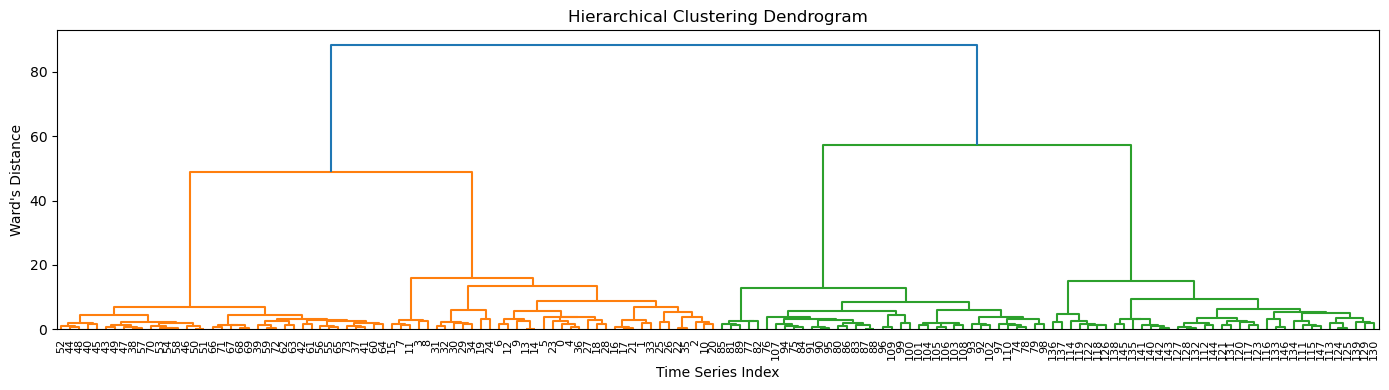

ARI for Agglomerative Clustering: 1.000
Silhouette Score: 0.629


In [34]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 1. Compute the Linkage Matrix
Z = linkage(cluster_paa, method='ward') # Using PAA data here

# 2. Plot the Dendrogram
plt.figure(figsize=(14, 4))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Time Series Index")
plt.ylabel("Ward's Distance")

dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)
plt.tight_layout()
plt.show()

# 3. Extracting the actual labels
agg_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
agg_labels = agg_model.fit_predict(cluster_paa)

print(f"ARI for Agglomerative Clustering: {adjusted_rand_score(cluster_data_labels, agg_labels):.3f}")
print(f"Silhouette Score: {silhouette_score(cluster_paa, agg_labels, metric='euclidean'):.3f}")

## 3. K-Means
K-Means is a widely applied clustering algorithm that **randomly** selects $k$ starting points from the data. These so called **centroids** are then **updated** to the new mean when data is added to the clusters.

For time series, native k-Means might not always be the best option. Time series can be understood to belong to the same cluster, even when they are **out of phase**. This is because the points in Euclidean Space have entirely different coordinates, which in turn affects ED as a similarity measure. <br>
For example, imagine recording the daily electrical consumption of two identical households, but one family simply wakes up and starts their appliances an hour later than the other. Because standard k-Means rigidly compares values at the exact same timestamps, it would calculate a massive Euclidean distance between the two series and could mistakenly place them in entirely different clusters.

There are approaches that use DTW distance to tackle that problem but they require a different centroid update. `tslearn.clustering.TimeSeriesKMeans` applies this - see the exercises in the end for more context.

### 3.1. Implementation

There are two implementations, one updating the clusters **incrementally** (MacQueen, 1967) and **batchwise** (LLoyd, 1957). LLoyd's algorithm finishes when the centroids are stable or after a fixed number of iterations. MacQueen's algorithm simply assigns the data to the clusters and updates the centroids until every data point has been processed.

Although k-Means nowadays stands for Lloyd's algorithm, the survey cited MacQueen's algorithm which we follow here as well.

As the initial centroids are selected randomly, they can perform badly when taken from the same cluster. **k-Means++** is an evolution of the algorithm that chooses the initial centroids in a more principled manner. 

In [ ]:
def kmeans(data, k_clusters):
    n_samples, n_features = data.shape

    random_indices = np.random.choice(n_samples, k_clusters, replace=False)
    centroids = data[random_indices].copy().astype(float)
    weights = np.ones(k_clusters, dtype=int)

    for i in range(k_clusters, n_samples):
        candidate = data[i]

        distances = np.linalg.norm(centroids - candidate, axis=1)
        idx = np.argmin(distances)

        centroids[idx] = (centroids[idx] * weights[idx] + candidate) / (weights[idx] + 1)
        weights[idx] += 1

    labels = np.zeros(n_samples, dtype=int)
    for i in range(n_samples):
        distances = np.linalg.norm(centroids - data[i], axis=1)
        labels[i] = np.argmin(distances)

    return labels, centroids

### 3.2. Exploration

Luckily, we already know the number of clusters from our synthetic split. However, let's still evaluate whether the elbow plot would align with our ground truth:

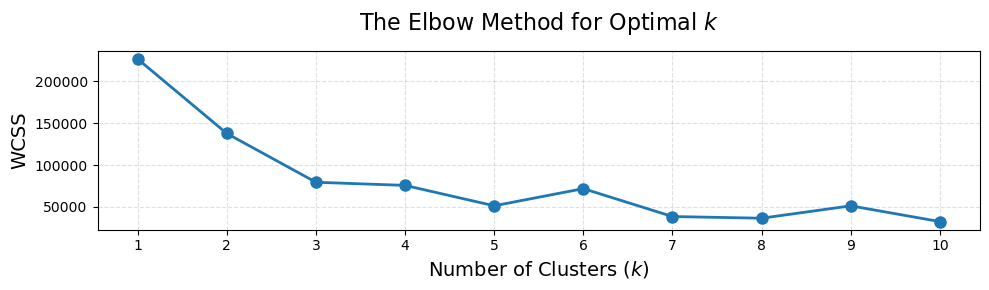

In [8]:
plot_elbow(cluster_data, kmeans)

Let's search for our $k$ clusters. The ARI and Silhouette Score for k-Means' clustering are calculated. The following plot shows the centroids and the time series assigned to them:

ARI: 0.652
Silhouette Score: 0.283


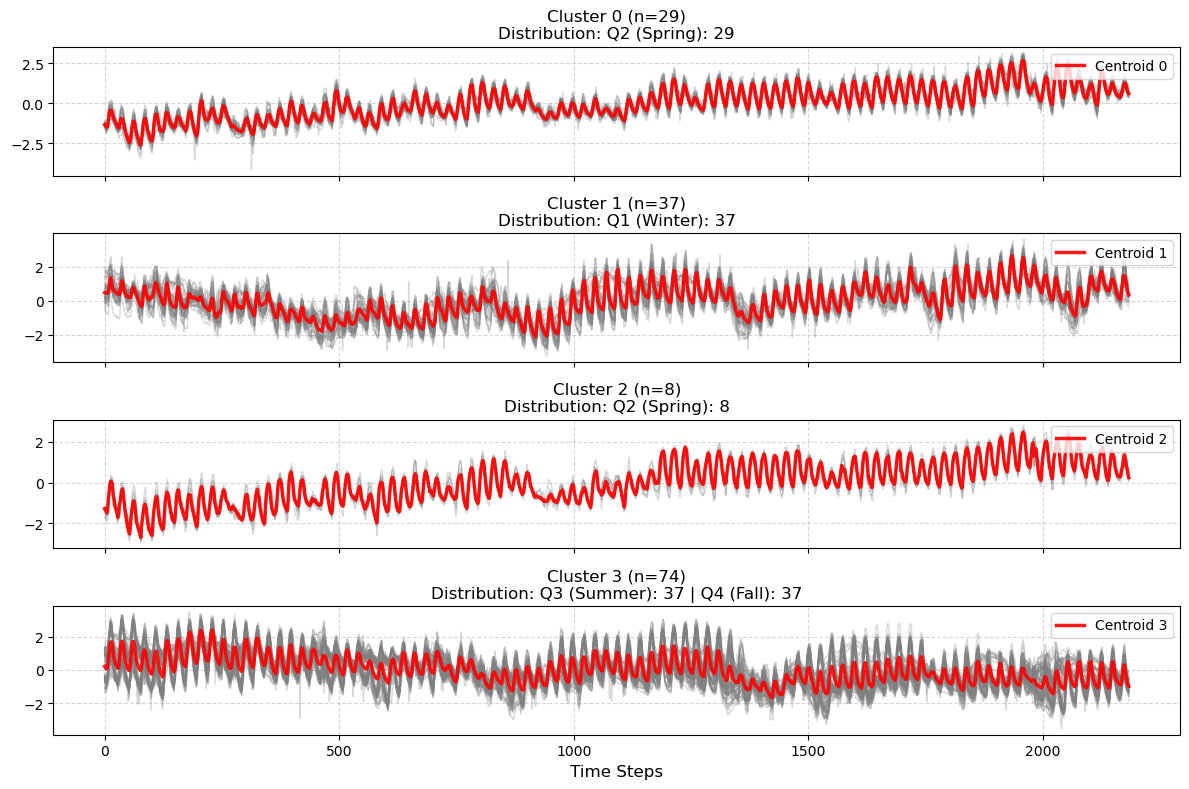

In [9]:
k = 4
kmeans_labels, kmeans_centroids = kmeans(cluster_data, k)

# Determine Clustering Quality
print(f"ARI: {adjusted_rand_score(cluster_data_labels, kmeans_labels):.3f}")
print(f"Silhouette Score: {silhouette_score(cluster_data, kmeans_labels, metric='euclidean'):.3f}")

# Plot Clusters
fig, axs = plt.subplots(k, 1, figsize=(12, 2 * k), sharex=True)
for cluster_id in range(k):
    assigned_indices = np.where(kmeans_labels == cluster_id)[0]
    ax = axs[cluster_id]
    
    # 1. Fetch the true labels for only the time series in this specific cluster
    true_labels_in_cluster = cluster_data_labels[assigned_indices]
    
    # 2. Count the occurrences of each true season
    unique_labels, counts = np.unique(true_labels_in_cluster, return_counts=True)
    
    # 3. Format into a clean string (e.g., "Q1 (Winter): 45, Q2 (Spring): 5")
    distribution_str = " | ".join([f"{label}: {count}" for label, count in zip(unique_labels, counts)])
    
    # Plot the time series
    for idx in assigned_indices:
        ax.plot(cluster_data[idx, :], color='gray', alpha=0.3, linewidth=1)
    
    # Plot the centroid
    ax.plot(kmeans_centroids[cluster_id, :], color='red', alpha=0.9, linewidth=2.5, label=f'Centroid {cluster_id}')
    
    # Add the distribution string directly to the title
    ax.set_title(f'Cluster {cluster_id} (n={len(assigned_indices)})\nDistribution: {distribution_str}', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

plt.xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()

## 4. K-Shapes

K-Shapes follows a similar idea as k-Means, but tackles its problem with phase shifts. 

By implementing a different similarity measure called **Shape-Based Distance** (SBD), phase shifts are not influential to the similarity anymore. One could argue that DTW already fullfills the same job. However, DTW's runtime over many time series is often unfeasable. SBD achieves a faster similarity measure that performed similarly well in the papers experiments.

K-Shapes also differs in the computation of a new centroid, which makes up most of its runtime.

### 4.1. Shape-based Distance

SBD relies on **Cross-Correlation**. By calculating the corelation of every **shift** of one time series to the other, only the **shape** of the data is compared and not their absolute values - especially as k-Shapes demands z-normalized data. 

It then normalizes the cross-correlation and searches for the alignment that maximizes its values. To make correlation a **distance**, it can be subtracted from 1 - this yields values between 0 (perfect alignment) and 2 (perfect mismatch). It can natively return a shifted input so both time series align.

Cross-Correlation is naively in $\mathcal{O}(n^2)$. However, the **convolution theorem** states that a convolution of two series can be calculated through the Inverse DFT of the dot product of the individual DFTs. A visual introduction to convolution by 3blue1brown can be found [here](https://www.youtube.com/watch?v=KuXjwB4LzSA).

To gain cross-correlation from convolution, one of the input time series is flipped in time - this can be expressed as taking the conjugate in the frequency domain (terminology for flipping the complex sign of the time series' DFT). As DFT can be calculated through FFT in $\mathcal{O}(n \log n)$, SBD is faster than DTW.

### 4.2. Centroid Updates

The **shape extraction** algorithm calculates the SBD of a query against all other given time series. For each time series, it stores its aligned version to the query.

From these alignments, a new centroid is calculated. While classic k-Means aligns a cluster's centroid to the average of its items, k-Shapes tries to maximize the centroid's shape similarity to all cluster items. <br>
It reduces this maximization problem to maximizing the **Rayleigh Quotient**. It uses a scatter matrix $S = X^T \cdot X$ that holds the dot product of all query-aligned time series. It is further using a normalization matrix $Q = I - \frac{1}{m}O$ (where $O$ is matrix with all 1s) which produces a mean of 0, a final matrix $M = Q^T \cdot S \cdot Q$ is achieved. The longest eigenvector of that matrix is our maximizing centroid.

In [10]:
def shape_based_distance(sequence_a, sequence_b, return_shifted=False):
    m = len(sequence_a)
    fft_len = 1 << (2 * m - 1).bit_length() # For even faster FFT

    # 1: Perform Convolution Theorem Cross Correlation
    cross_correlation = np.fft.irfft(np.fft.rfft(sequence_a, fft_len) * np.conj(np.fft.rfft(sequence_b, fft_len)))
    cross_correlation = np.concatenate((cross_correlation[-(m - 1):], cross_correlation[:m]), axis=0)

    coeff_norm_cross_correlation = cross_correlation / (np.linalg.norm(sequence_a) * np.linalg.norm(sequence_b))

    # 2: Find best alignment
    index = np.argmax(coeff_norm_cross_correlation)
    value = coeff_norm_cross_correlation[index] 

    # 3: Calculate Distance and Shift from alignement
    dist = 1 - value
    shift = index - (m - 1)
    
    # 4: Shift input time series for match
    if shift > 0:
        sequence_b_shifted = np.concatenate((np.zeros(shift), sequence_b[:-shift]))
    elif shift < 0:
        sequence_b_shifted = np.concatenate((sequence_b[-shift:], np.zeros(-shift)))
    else:
        sequence_b_shifted = sequence_b.copy()
    
    if return_shifted:
        return dist, sequence_b_shifted
    else:
        return dist

def shape_extraction(time_series_array, query):
    n_time_series, n_time_points = time_series_array.shape
    X = np.zeros((n_time_series, n_time_points)) # Hold aligned time series

    # Calculate SBD between query and all other timem series
    for i in range(n_time_series):
        _, shifted_time_series = shape_based_distance(query, time_series_array[i], return_shifted=True)
        X[i] = shifted_time_series

    # Frame the centroid computation as a Rayleigh Quotient maximization problem
    S = X.T @ X
    Q = np.identity(n_time_points) - (1.0 / n_time_points) * np.ones((n_time_points, n_time_points))
    M = Q.T @ S @ Q

    # Find new centroid position through eigenvalue decomposition
    evals, evecs = np.linalg.eigh(M)
    optimum_centroid = evecs[:, np.argmax(evals)]

    # Account for eigenvector direction: Centroid should align with time series
    if np.dot(optimum_centroid, query) < 0:
        optimum_centroid = -optimum_centroid

    return zscore(optimum_centroid)
    

### 4.3. Implementation

The k-Shape algorithm first initializes centroids at 0 and random cluster assignments. It then enters a loop that ends when the clusters are stable or a set number of iterations is exceeded.

**Note that during testing it occurred that k-Shape faces the same danger with random cluster initialization as k-Means!**<br> We have chosen a random seed that showcases the strength of k-Shapes. However, in a real setting either taking the best of several approaches or using k-Means++ initialization would be more robust.

For each cluster, the centroid is updated given the shape extraction algorithm. Then, each time series gets assigned to the new centroids given the SBD to the respective cluster centroids.

However, k-Shape scales linearly with the number of time series $n$, but quadratically or even cubically with the time series length $m$. They assume, that $m \gg n$ which aligns with the UCR archive but is obviously not the case with our weather data. Thus, either segmentation or dimensioanlity reduction can be used - we will use Piecewise Aggregate Approximation (PAA).

In [11]:
def kshape(time_series_array, k_clusters, random_seed=256):
    n_time_series, n_time_points = time_series_array.shape
    iter = 0
    random_state = np.random.RandomState(random_seed) # For Showcasing!!

    # 1: Initialize k centroids and clusters
    centroids = np.zeros((k_clusters, n_time_points))

    cluster_assignments = random_state.randint(0, k_clusters, n_time_series)
    cluster_assignments_new = cluster_assignments.copy() - 1

    # 2: Start clustering
    while not np.equal(cluster_assignments, cluster_assignments_new).all() and iter < 100:
        cluster_assignments_new = cluster_assignments.copy()

        # 2.1: Update centroids
        for j in range (k_clusters):
            if np.all(centroids[j] == 0):
                reference = time_series_array[random_state.randint(0, len(time_series_array))]
            else:
                reference = centroids[j]
        
            centroids[j] = shape_extraction(time_series_array[cluster_assignments == j], reference)

        # 2.2: Resort time series to updated centroids
        for i in range(n_time_series):
            mindist = np.inf

            for j in range(k_clusters):
                dist = shape_based_distance(centroids[j], time_series_array[i])
                
                if dist < mindist:
                    mindist = dist
                    cluster_assignments[i] = j

        iter += 1

    return cluster_assignments, centroids

### 4.4. Exploration

Let's plot an elbow plot for k-Shapes again. As mentioned above, we will use PAA to deal with the time series length.

/home/moritz/miniconda3/envs/unibz-tsa-examples/lib/python3.14/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


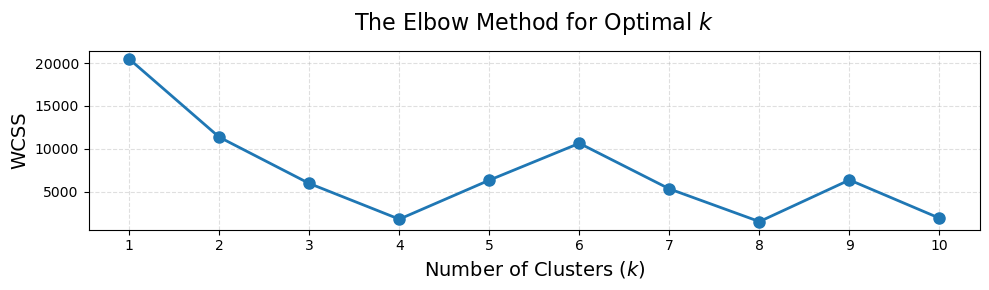

In [ ]:
plot_elbow(cluster_paa, kshape)

Let's view the k-Shapes Clustering Results:

ARI: 0.9818574667403797
Silhouette Score (ED): 0.628
Silhouette Score (SBD): 0.801


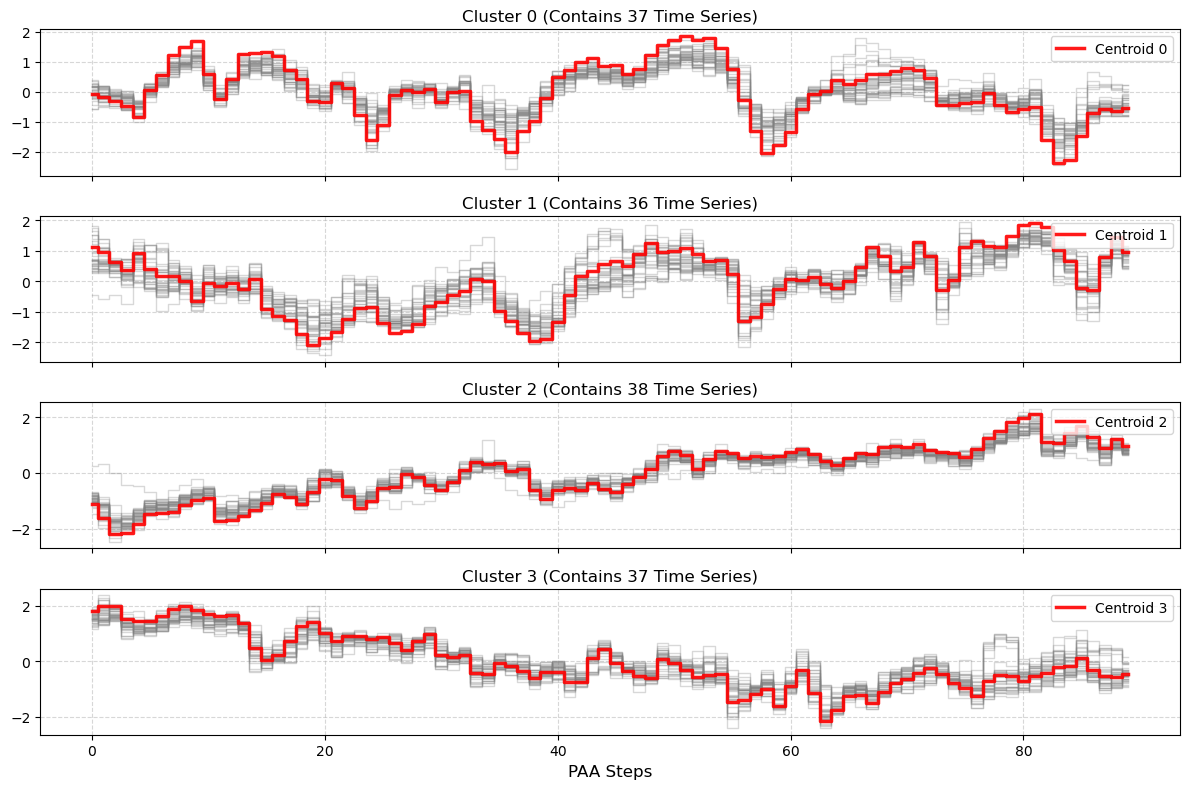

In [13]:
k = 4
kshape_labels, kshape_centroids = kshape(cluster_paa, k)

print(f"ARI: {adjusted_rand_score(cluster_data_labels, kshape_labels)}")
print(f"Silhouette Score (ED): {silhouette_score(cluster_paa, kshape_labels, metric="euclidean"):.3f}")
print(f"Silhouette Score (SBD): {silhouette_score(cluster_paa, kshape_labels, metric=shape_based_distance):.3f}")

# Plot clustering
fig, axs = plt.subplots(k, 1, figsize=(12, 2 * k), sharex=True)

for cluster_id in range(k):
    # Find the indices of all time series assigned to the current cluster
    assigned_indices = np.where(kshape_labels == cluster_id)[0]
    
    # Select a specific subplot axis
    ax = axs[cluster_id]
    
    # Plot all individual time series belonging to this cluster in a faint gray color
    for idx in assigned_indices:
        ax.step(np.arange(0, n_paa_segments), cluster_paa[idx, :], color='gray', alpha=0.3, linewidth=1, where="mid")
    
    # Overlay the Cluster Centroid (the average representative shape) in bold red
    ax.step(np.arange(0, n_paa_segments), kshape_centroids[cluster_id, :], where="mid", color='red', alpha=0.9, linewidth=2.5, label=f'Centroid {cluster_id}')
    
    # Aesthetic adjustments
    ax.set_title(f'Cluster {cluster_id} (Contains {len(assigned_indices)} Time Series)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

# Set a shared X-axis label at the bottom
plt.xlabel('PAA Steps', fontsize=12)
plt.tight_layout()
plt.show()

## 5. DBSCAN

**Density** Based Spatial Clustering of Applications with Noise (DBSCAN) is a common clustering algorithm. It allows any number of **clusters** and differentiates between clusters and **noise**, i.e. values that do not belong to any cluster. In contrast, k-Means and k-Shape assign a cluster to each value. The algorithm uses two helper functions:

### 5.1. Implementation
To query all points within a **region** of a target, the authors of DBSCAN suggest spatial access methods such as **R\*-trees**. Because of the high dimensionality of time series data, a lot of these spatial indexes are losing their advantage. Thus, we implemented a simple serial scan which would be an important runtime bottleneck in real settings.

To **expand** an existing cluster, DBSCAN checks whether a point is a **core point** or noise. It then continously appends all candidates for evaluation in the growing cluster and stops only if no new candidates appear. Every candidate is assigned the cluster except it already belongs to another.

In [14]:
UNCLASSIFIED = 0
NOISE = -1

def region_query(set_of_points, point_idx, eps):
    # Fetch time series
    point = set_of_points[point_idx]
    
    # Calculate all neighbors through serial scan
    distances = np.linalg.norm(set_of_points - point, axis=1)
    neighbors = np.where(distances <= eps)[0]

    return neighbors.tolist()

def expand_cluster(set_of_points, labels, point_idx, cluster_id, eps, min_pts):
    # 1: Fetch all neighboring time series
    seeds = region_query(set_of_points, point_idx, eps)

    # 2: Assign noise when not core point
    if len(seeds) < min_pts:
        labels[point_idx] = NOISE
        return False
    
    # 3: Assign cluster to neighbors
    for idx in seeds:
        labels[idx] = cluster_id

    seeds.remove(point_idx)

    # 4: Expand for all time series close to the cluster
    while len(seeds) > 0:
        current_point = seeds[0]

        # 4.1: Get points in range of cluster
        result = region_query(set_of_points, current_point, eps)

        # 4.2: Assign cluster to all points in range that are not yet assigned to another 
        if len(result) >= min_pts:
            for result_point in result:
                if labels[result_point] == UNCLASSIFIED or labels[result_point] == NOISE:

                    if labels[result_point] == UNCLASSIFIED:
                        seeds.append(result_point)

                    labels[result_point] = cluster_id
        
        # 4.3: Remove evaluated point from consideration
        seeds.pop(0)

    return True

DBSCAN initializes all points (time series) as **unclassified**, i.e. not belonging to a cluster or noise. One can specify the density parameter $\epsilon$ that says how close points need to be for belonging to the same cluster and the minimum number of points within a points region to be considered a **core point**. It expects z-normalized time series.

It then loops through all points and processes them if they are still unclassified. Note that a point can be assigned a cluster through the `expand_cluster()` method before being evaluated by the main loop.

If the point is unclassified and not noise, a new cluster starting from that point is initialized.

In [15]:
def dbscan(set_of_points, eps, min_pts):
    n_points = len(set_of_points) # A point is a time series
    
    # Initialize cluster assignments
    labels = np.full(n_points, UNCLASSIFIED)
    cluster_id = 1

    # Loop through points
    for i in range(len(set_of_points)):
        
        # Intialize cluster expansion if point is not yet part of any
        if labels[i] == UNCLASSIFIED:
            if expand_cluster(set_of_points, labels, i, cluster_id, eps, min_pts):
                cluster_id += 1

    return labels

### 5.2. Exploration
We are following the DBSCAN paremeter selection from the computational study / survey of the lecture. <br> They used an elbow method to determine the epsilon (radius around point) parameter by an elbow method for possible min_pts (how many neighbors to count as core point) of 5, 10 and 15. 

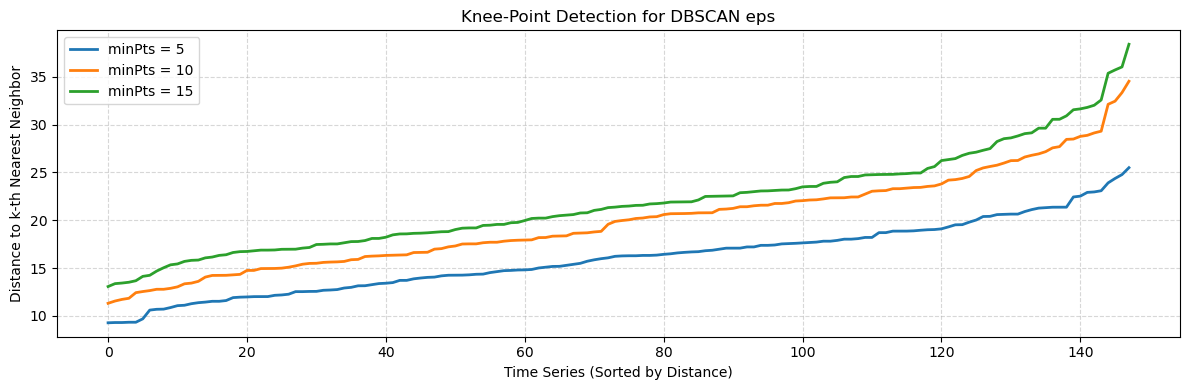

In [16]:
from sklearn.neighbors import NearestNeighbors

min_pts_candidates = [5, 10, 15]

plt.figure(figsize=(12, 4))
for i, min_pts_candidate in enumerate(min_pts_candidates):
    neighbors = NearestNeighbors(n_neighbors=min_pts_candidate)
    neighbors_fit = neighbors.fit(cluster_data)
    distances, indices = neighbors_fit.kneighbors(cluster_data)

    k_distances = np.sort(distances[:, min_pts_candidate - 1])
    plt.plot(k_distances, linewidth=2, label=f'minPts = {min_pts_candidate}')

plt.title('Knee-Point Detection for DBSCAN eps')
plt.xlabel('Time Series (Sorted by Distance)')
plt.ylabel('Distance to k-th Nearest Neighbor')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

We can observe the sharpest knee-point for $min\_pts = 5$ at 22, for $min\_pts = 10$ at 29 and for $min\_pts = 15$ at 33. The sharpest spike is for the latter two settings, indicating better configurations.

However, we are using the first one to showcase some DBSCAN properties. Namely, the number of clusters not being externally constrained (more than 4 clusters) and the classification of noise as a separate group.

For this dataset it seems like the Q1 / winter data shows the greatest variation which cannot be captured with an $\epsilon = 22$. Thus, DBSCAN identifies two clusters within the winter data and on top of that categorizes some as noise.

ARI: 0.932
Silhouette Score: 0.482


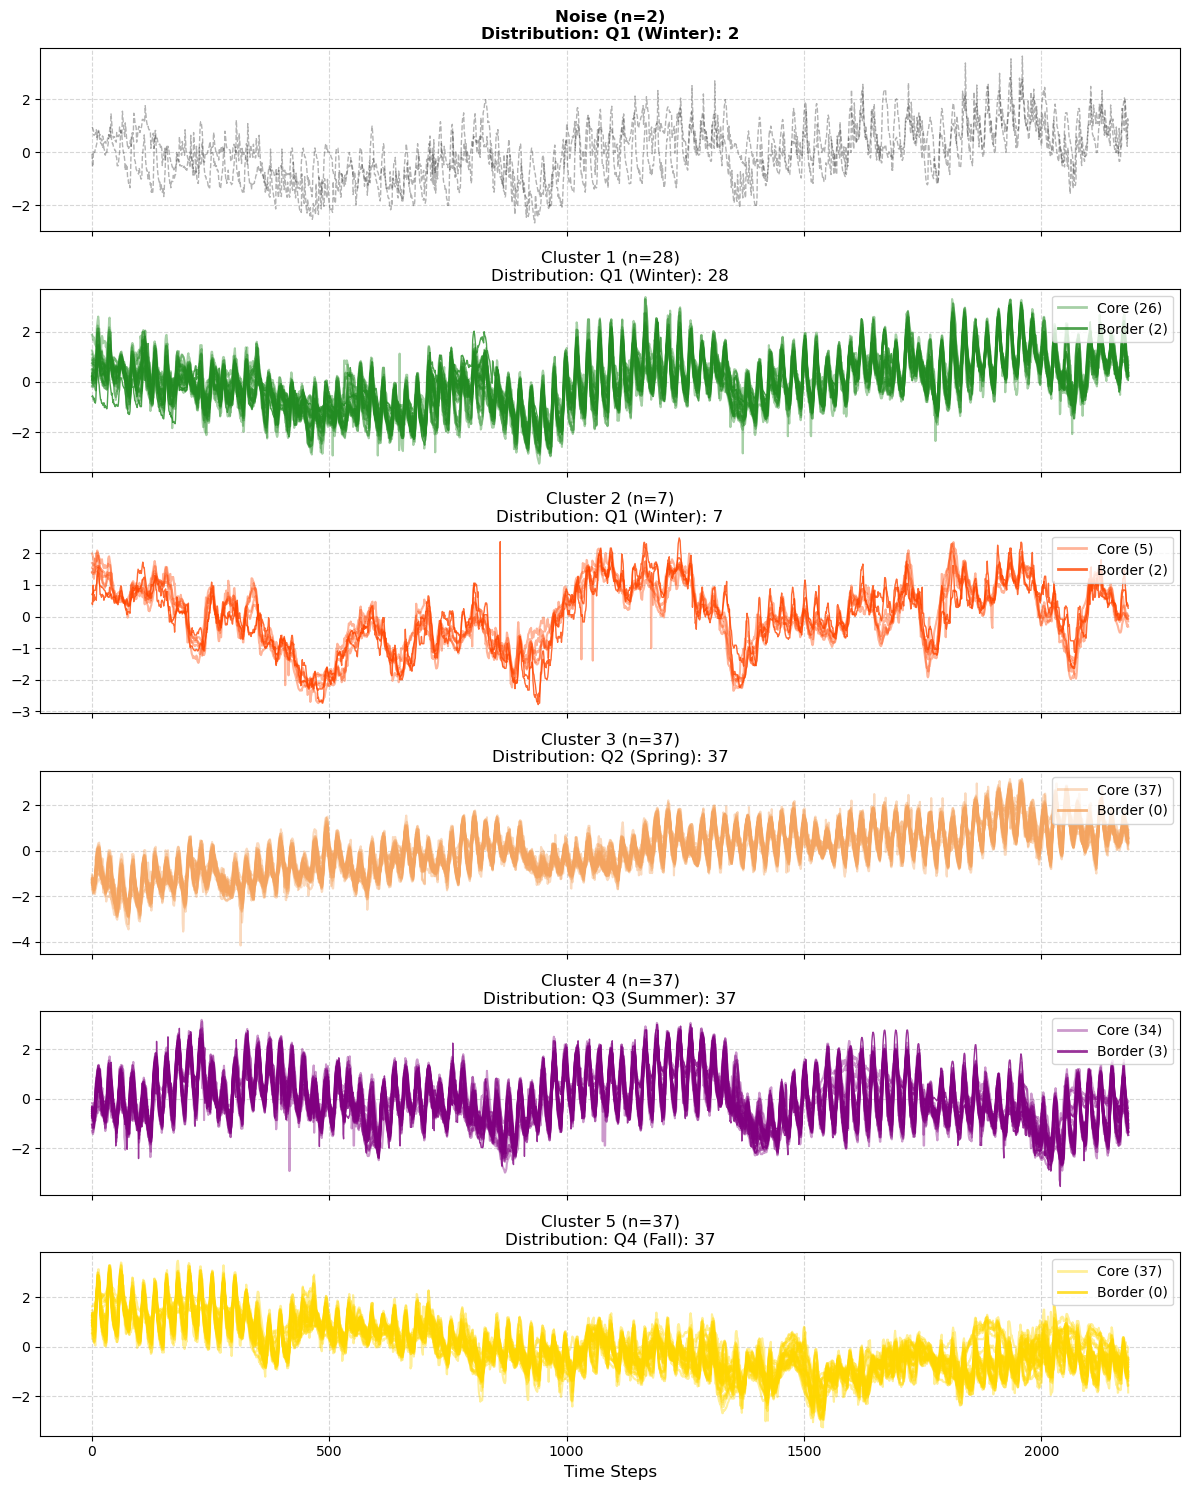

In [17]:
# Play with the parameters
min_core_neighbors = 5
radius = 22
dbscan_labels = dbscan(cluster_data, eps=radius, min_pts=min_core_neighbors)

# Calculate Metrics
print(f"ARI: {adjusted_rand_score(cluster_data_labels, dbscan_labels):.3f}")
print(f"Silhouette Score: {silhouette_score(cluster_data, dbscan_labels, metric="euclidean"):.3f}")

# Plot clusters
core_samples_mask = np.array([np.sum(np.linalg.norm(cluster_data - x, axis=1) <= radius) >= min_core_neighbors for x in cluster_data])
unique_labels = np.unique(dbscan_labels)
colors = ['deepskyblue', 'forestgreen', 'orangered', 'sandybrown', 'purple', 'gold']
fig, axs = plt.subplots(len(unique_labels), 1, figsize=(12, 2.5 * len(unique_labels)), sharex=True, squeeze=False)

for ax, label in zip(axs.flatten(), unique_labels):
    assigned = np.where(dbscan_labels == label)[0]
    u_trues, counts = np.unique(cluster_data_labels[assigned], return_counts=True)
    dist = " | ".join([f"{l}: {c}" for l, c in zip(u_trues, counts)])
    title_prefix = "Noise" if label == -1 else f"Cluster {label}"
    ax.set_title(f'{title_prefix} (n={len(assigned)})\nDistribution: {dist}', fontsize=12, fontweight='bold' if label == -1 else 'normal')
    
    if label == -1:
        ax.plot(cluster_data[assigned].T, color='black', alpha=0.3, linestyle='--', linewidth=1)
    else:
        c = colors[label % len(colors)]
        core, border = assigned[core_samples_mask[assigned]], assigned[~core_samples_mask[assigned]]
        
        ax.plot(cluster_data[core].T, color=c, alpha=0.4, linewidth=1.5)
        ax.plot(cluster_data[border].T, color=c, alpha=0.8, linewidth=1)
        ax.plot([], [], color=c, alpha=0.4, lw=2, label=f'Core ({len(core)})')
        ax.plot([], [], color=c, alpha=0.8, lw=2, label=f'Border ({len(border)})')
        ax.legend(loc='upper right')
        
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()

### 5.3. DBSCAN with PCA

If you look up time series clustering with DBSCAN, popular results are not working on the time series directly. Instead, they are utilizing **Principal Component Analysis (PCA)** and cluster the resulting dimensionality-reduced data. Arguably, the same can be done for k-Means.

With PCA, we reduce the complexity of time series to a more classical amount of clustering features. We are using a drastic reduction to 2 dimensions which allows a convenient plotting. 

In the case of dimensionality reduction, the min_pts has to be higher than the number of dimensions. The density parameter $\epsilon$ can then be determined by an elbow plot again. 

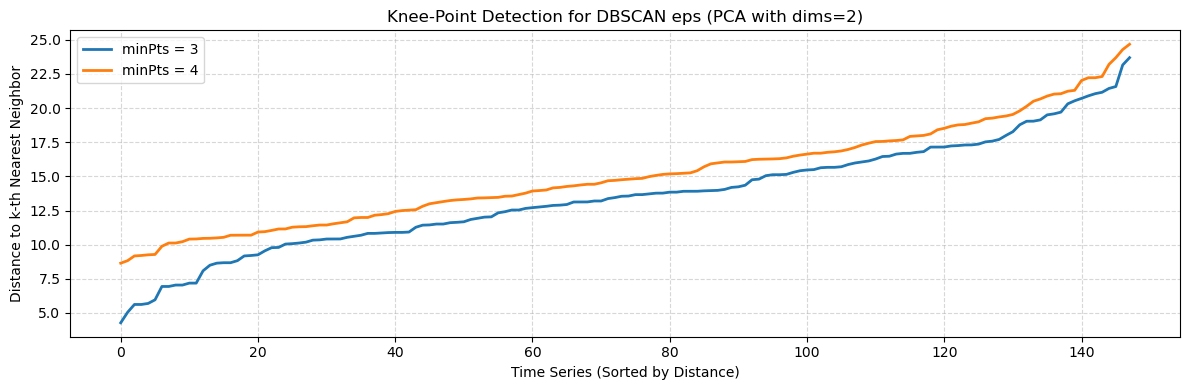

In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensions
dims = 2
pca = PCA(n_components=dims)
X_pca = pca.fit_transform(cluster_data)

# Define two min_pts options
min_pts_1 = dims + 1
min_pts_2 = 2 * dims

# Plotting an elbow-plot again
plt.figure(figsize=(12, 4))
for i, min_pts_candidate in enumerate([min_pts_1, min_pts_2]):
    neighbors = NearestNeighbors(n_neighbors=min_pts_candidate)
    neighbors_fit = neighbors.fit(cluster_data)
    distances, indices = neighbors_fit.kneighbors(cluster_data)

    k_distances = np.sort(distances[:, min_pts_candidate - 1])
    plt.plot(k_distances, linewidth=2, label=f'minPts = {min_pts_candidate}')

plt.title(f'Knee-Point Detection for DBSCAN eps (PCA with dims={dims})')
plt.xlabel('Time Series (Sorted by Distance)')
plt.ylabel('Distance to k-th Nearest Neighbor')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Here, a setting of $min\_pts = 3$ and $\epsilon = 6$ or $min\_pts = 4$ and $\epsilon = 9$ can be thought of good settings for the PCA data.

However, both only give 3 clusters when actually running on the data. We can still tune the $\epsilon$ parameter down to only allow denser clusters (e.g. $min\_pts = 3$, $\epsilon = 5$) - this results in a perfect clustering of the data even after PCA. 

We again chose a setting with an even lower $\epsilon$ to showcase noise and more cluster labels. The transparent circles represent the ground truth clusters while the dots and their color represent the clusters assigned by DBSCAN.

ARI: 0.928
Silhouette Score: 0.729


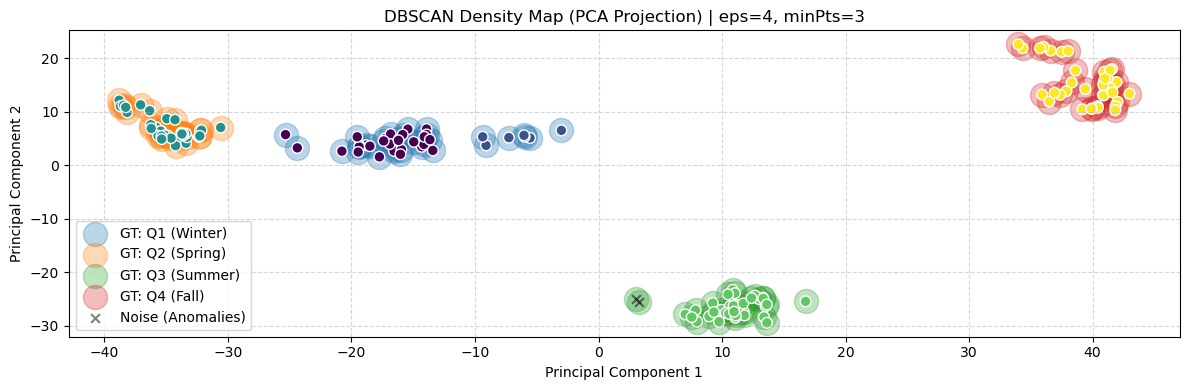

In [19]:
# Play with the parameters
min_pts = 3
eps = 4
dbscan_pca_labels = dbscan(X_pca, min_pts=min_pts, eps=eps)

# Calculate Metrics
print(f"ARI: {adjusted_rand_score(cluster_data_labels, dbscan_pca_labels):.3f}")
print(f"Silhouette Score: {silhouette_score(X_pca, dbscan_pca_labels, metric="euclidean"):.3f}")

# Plotting PCA in 2D
plt.figure(figsize=(12, 4))
noise_mask = (dbscan_pca_labels == -1)

for i, label in enumerate(np.unique(cluster_data_labels)):
    mask = (cluster_data_labels == label)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=300, alpha=0.3, label=f'GT: {label}')

plt.scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1], c=dbscan_pca_labels[~noise_mask], s=60, edgecolor='white')
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='black', marker='x', s=40, alpha=0.5, label='Noise (Anomalies)')

plt.title(f'DBSCAN Density Map (PCA Projection) | eps={eps}, minPts={min_pts}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Exercises

### 6.1. Data
The popular [UCR Time Series Classification Archive](https://www.cs.ucr.edu/~eamonn/time_series_data_2018/) was used as the benchmark by the survey presented in the lecture. While we used weather data as an intuitive example, researchers often evaluate their clustering and classification models against these datasets.

**Task:**
1. Download the `"Trace"` dataset (or another of your choice) using `tslearn`.
2. Choose one of the clustering algorithms from this lecture (K-Means, K-Shapes, or DBSCAN).
3. Cluster the dataset and evaluate your results using the Adjusted Rand Index (ARI) against the provided ground truth labels.

In [20]:
from tslearn.datasets import UCR_UEA_datasets

# 1. Load the dataset
ucr = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ucr.load_dataset("Trace")

# Flatten the 3D tslearn array to 2D for our custom algorithms
X_train_2d = X_train[:, :, 0]

# TODO: Apply a clustering algorithm of your choice to X_train_2d

# TODO: Calculate and print the ARI using y_train as the ground truth

As discussed, clustering algorithms that rely on Euclidean Distance are highly vulnerable to phase shifts. 

Tasks:
1. Introduce a random phase shift into the weather data. Note that the algorithms implemented in this notebook require all time series to be of the exact same length (a circular shift is ideal here).

2. Compare the performance of k-Means to k-Shapes on this misaligned data. Does k-Means perform worse while k-Shapes maintains its accuracy, as one would expect?
3. Furthermore, you can evaluate DBSCAN, which currently relies on Euclidean Distance as well. Try implementing Shape-Based Distance (SBD) in the `region_query()` method. Does it help DBSCAN overcome the phase shifts?

In [ ]:
# 1. Artificially phase-shift the existing weather data by a random number of hours (e.g., 1 to 4 weeks)
# Using np.roll shifts the data circularly, ensuring the time series remain the exact same length.
random_shifts = np.random.randint(24 * 7, 24 * 28, size=len(cluster_data))
cluster_data_shifted = np.array([np.roll(ts, shift) for ts, shift in zip(cluster_data, random_shifts)])

# ==========================================
# 2. Evaluate K-Means
# ==========================================
# TODO: Initialize and fit sklearn's KMeans (n_clusters=4) on cluster_data_shifted


# TODO: Calculate and print the ARI for K-Means


# ==========================================
# 3. Evaluate K-Shapes
# ==========================================
# TODO: Apply PAA to cluster_data_shifted (remember to expand dimensions for tslearn!)


# TODO: Run our custom kshape() function on the PAA-reduced shifted data


# TODO: Calculate and print the ARI for K-Shapes

In [ ]:
# ==========================================
# 4. Evaluate DBSCAN (Euclidean vs. SBD)
# ==========================================
# TODO: Run your standard dbscan() on cluster_data_shifted and calculate the ARI


# TODO: Scroll up to the DBSCAN implementation cell, modify `region_query()` to accept 
# distance="SBD", re-run the algorithm on cluster_data_shifted, and compare the ARIs!

### 6.2. k-Means
Our custom `kmeans` function implemented MacQueen's online update approach. Standard `sklearn` implements Lloyd's algorithm (batch updates) and uses `k-means++` for smart centroid initialization. 

**Task:**
1. Cluster the provided synthetic sine wave data using both our custom `kmeans()` function, `sklearn.cluster.KMeans` and `sklearn.cluster.kmeans_plus_plus`.
2. Compare the execution time and ARI of both approaches.

In [21]:
from sklearn.cluster import KMeans

# TODO Execute KMeans with init="random"

# TODO Execute KMeans with init="k-means++"

# TODO Compare both results to our k-Mean and k-Shapes implementation

The `tslearn` library also implements a `kmeans` function explicitly for time series.

One can specify DTW as a distance measure. For a correct centroid update it then uses DTW Barycenter Averaging (DBA) instead of simple averages. 

DBA is an iterative algorithm that calculates the mean of a group of time series by first temporally aligning them using Dynamic Time Warping. This ensures that the resulting centroid preserves the actual morphological shape and structural peaks of the sequences, rather than flattening them out like a standard Euclidean average would.

In [22]:
from tslearn.clustering import TimeSeriesKMeans

# TODO Execute TimeSeriesKMeans with metric="DTW"

### 6.3. k-Shapes
The standard K-Means (and K-Shapes) algorithm often struggles because its initial centroids are selected completely at random. If two initial centroids are randomly placed inside the same true cluster, the algorithm can easily get stuck in a poor local minimum.

The **K-Means++** procedure fixes this by forcing the initial centroids to be spread out:
1. The first centroid is chosen entirely at random from the dataset.
2. For every remaining data point, the algorithm calculates its distance to the nearest already-chosen centroid.
3. The next centroid is chosen randomly from the data, but with a probability proportional to its squared distance from the existing centroids (meaning points furthest away have the highest chance of being picked).
4. Steps 2 and 3 repeat until all $k$ centroids are selected.

**Task:**
1. Run the standard `kshape()` function 10 times. Track and print the labels from the run that produced the highest total Silhouette Score.

2. Change the `kshape()` function implement the K-Means++ selection logic, but substitute Euclidean distance with our custom **Shape-Based Distance (SBD)**.

In [23]:
best_wcss = np.inf
best_labels = None
k = 4
n_runs = 10

for run in range(n_runs):
    # Note: To make this work, ensure you change the the default random_state inside kshape
    
    # TODO: Run your custom kshape(cluster_paa, k) 
    
    # TODO: Calculate WCSS for this run (sum of SBD from each time series to its assigned centroid)
    current_wcss = 0 
    
    # TODO: If current_wcss < best_wcss, update the best_wcss and best_labels variables
    
print(f"Best overall WCSS achieved across {n_runs} runs: {best_wcss}\n")

Best overall WCSS achieved across 10 runs: inf



In [24]:
def kshape_plusplus(time_series_array, k_clusters, random_seed=256):
    n_time_series, n_time_points = time_series_array.shape
    iter_count = 0
    random_state = np.random.RandomState(random_seed) 
    
    # ================================================================================================
    # 1. INITIALIZATION (K-Means++ logic with SBD)
    # ================================================================================================
    centroids = []
    
    # Pick the first centroid randomly
    first_idx = random_state.randint(0, n_time_series)
    centroids.append(time_series_array[first_idx])

    # Iterate to find the remaining k-1 centroids
    for _ in range(1, k_clusters):
        distances = np.zeros(n_time_series)
        
        # TODO: For each time series in 'time_series_array':
        #   a. Loop through the currently chosen 'centroids' and calculate the SBD.
        #   b. Find the MINIMUM distance (distance to its closest centroid).
        #   c. Store this minimum distance in the 'distances' array at index i.
        for i in range(n_time_series):
            min_dist = np.inf
            # Write your loop here...
            
            distances[i] = min_dist
        
        # Choose the next centroid proportionally
        # TODO: Calculate probabilities proportional to these minimum distances (or their squares).
        # Hint: Normalize the distances array by dividing it by its sum.
        # probabilities = ...
        
        # TODO: Use random_state.choice to select the next centroid index based on 'probabilities',
        # and append the actual time series to the 'centroids' list.
        # next_idx = ...
        # centroids.append(time_series_array[next_idx])

    centroids = np.array(centroids)
    # ================================================================================================

    # Set up tracking arrays for the loop
    cluster_assignments = np.zeros(n_time_series, dtype=int)
    cluster_assignments_new = np.full(n_time_series, -1, dtype=int)

    # 2: Start clustering
    # The loop order must be Assign -> Update when using pre-initialized centroids!
    while not np.equal(cluster_assignments, cluster_assignments_new).all() and iter_count < 100:
        cluster_assignments_new = cluster_assignments.copy()

        # 2.1: Assign time series to the closest existing centroid
        for i in range(n_time_series):
            mindist = np.inf
            for j in range(k_clusters):
                dist = shape_based_distance(centroids[j], time_series_array[i])
                if dist < mindist:
                    mindist = dist
                    cluster_assignments[i] = j

        # 2.2: Update centroids to reflect the new cluster assignments
        for j in range(k_clusters):
            cluster_members = time_series_array[cluster_assignments == j]
            if len(cluster_members) > 0:
                # We pass the old centroid as the reference for shape extraction
                centroids[j] = shape_extraction(cluster_members, centroids[j])
            else:
                # Failsafe: if a cluster becomes empty, pick a random point
                centroids[j] = time_series_array[random_state.randint(0, n_time_series)]

        iter_count += 1

    return cluster_assignments, centroids

### 6.4. DBSCAN

One of the biggest struggles with DBSCAN is selecting the $\epsilon$ parameter, especially if data clusters have varying densities. The **OPTICS** algorithm relaxes this strict distance requirement.

**Task:**
1. Apply `sklearn.cluster.OPTICS` to our PCA-reduced weather dataset (`X_pca`).
2. Compare the resulting cluster labels to our DBSCAN output. 
3. Bonus: Plot the OPTICS *Reachability Plot* using `model.reachability_[model.ordering_]`.

In [25]:
from sklearn.cluster import OPTICS

# TODO: Initialize OPTICS with min_samples


# TODO: Fit to X_pca and extract the labels


# TODO: Calculate ARI and Silhouette Score compared to ground truth


# TODO Plot the Reachability Distances

### 6.5. Other Clustering

**BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)** is a highly scalable clustering algorithm designed for massive datasets. Instead of scanning the entire dataset iteratively like k-Means, it builds a memory-efficient summary structure called a Clustering Feature (CF) Tree in a single pass. While it is incredibly fast and conceptually elegant, it relies on a threshold radius to determine cluster boundaries.

**Gaussian Mixture Models (GMM)** offer a probabilistic approach, introducing the concept of **soft clustering**. Unlike K-Means or BIRCH, which strictly assign each time series to exactly one cluster (hard clustering), GMM assumes the data is generated from a mixture of underlying Gaussian distributions. It calculates the probability that a sequence belongs to a specific cluster.

In [26]:
from sklearn.cluster import Birch

# TODO: Initialize Birch with n_clusters and a threshold
birch_model = Birch() 

# TODO: Fit the model to X_pca and extract the labels

In [27]:
from sklearn.mixture import GaussianMixture

# TODO: Initialize a GaussianMixture model with n_components
gmm_model = GaussianMixture()

# TODO: Fit the model to X_pca

# TODO: Get the hard cluster assignments using predict()

# TODO: Extract the soft clustering probabilities using predict_proba()
# probabilities = gmm_model.predict_proba(X_pca)